<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/Kmeans%26ElboMethod/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown 13vTkYO5hTI5vjpQosk2P5rMj2QvUUvNu


Downloading...
From: https://drive.google.com/uc?id=13vTkYO5hTI5vjpQosk2P5rMj2QvUUvNu
To: /content/Online_Retail.csv
100% 46.1M/46.1M [00:01<00:00, 35.4MB/s]


In [ ]:
# Importing Libraries
import pandas as pd

# For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# To scale our data
from sklearn.preprocessing import scale

# To perform K-Means clustering
from sklearn.cluster import KMeans

In [ ]:
# reading dataset
retail = pd.read_csv("Online_Retail.csv",  sep=',', encoding="ISO-8859-1", header=0)

# parse date
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], format = "%d-%m-%Y %H:%M")

In [ ]:
# Let's look at the top 5 rows
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# NA handling
retail.isnull().values.any()
retail.isnull().values.sum()
retail.isnull().sum()*100/retail.shape[0]

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [ ]:
# dropping the na cells
order_wise = retail.dropna()

In [ ]:
order_wise.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
# RFM implementation

# Extracting the amount by multiplying quantity and unit price and saving the data into the amount variable.
amount  = pd.DataFrame(order_wise.Quantity * order_wise.UnitPrice, columns = ["Amount"])
amount.head()

,Amount
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34


# Monetary Value

In [ ]:
# merging amounts in order of
order_wise = pd.concat(objs = [order_wise, amount], axis = 1, ignore_index = False)

# Monetary function
# finding total amount spent per customer
monetary = order_wise.groupby("CustomerID").Amount.sum()
monetary = monetary.reset_index()
monetary.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


# Frequency Value


In [ ]:
# Frequency function
frequency = order_wise[['CustomerID', 'InvoiceNo']]

In [ ]:
# getting the count of orders made by each customer based on customer ID.
k = frequency.groupby("CustomerID").InvoiceNo.count()
k = pd.DataFrame(k)
k = k.reset_index()
k.columns = ["CustomerID", "Frequency"]
k.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [ ]:
# creating master dataset
master = monetary.merge(k, on = "CustomerID", how = "inner")
master.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


# Recency Value

In [ ]:
recency  = order_wise[['CustomerID', 'InvoiceDate']]
maximum = max(recency.InvoiceDate)

In [ ]:
recency

,CustomerID,InvoiceDate
0,17850.0,2010-12-01 08:26:00
1,17850.0,2010-12-01 08:26:00
2,17850.0,2010-12-01 08:26:00
3,17850.0,2010-12-01 08:26:00
4,17850.0,2010-12-01 08:26:00
...,...,...
541904,12680.0,2011-12-09 12:50:00
541905,12680.0,2011-12-09 12:50:00
541906,12680.0,2011-12-09 12:50:00
541907,12680.0,2011-12-09 12:50:00


In [ ]:
maximum

Timestamp('2011-12-09 12:50:00')

In [ ]:
# generating recency function

# filtering data for customerid and invoice_date
recency  = order_wise[['CustomerID', 'InvoiceDate']]

# finding max data
maximum = max(recency.InvoiceDate)

# adding one more day to the max data, so that the max date will have 1 as the difference and not zero.
maximum = maximum + pd.DateOffset(days=1)
recency['diff'] = maximum - recency.InvoiceDate
recency.head()

/tmp/ipython-input-1468527610.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recency['diff'] = maximum - recency.InvoiceDate


,CustomerID,InvoiceDate,diff
0,17850.0,2010-12-01 08:26:00,374 days 04:24:00
1,17850.0,2010-12-01 08:26:00,374 days 04:24:00
2,17850.0,2010-12-01 08:26:00,374 days 04:24:00
3,17850.0,2010-12-01 08:26:00,374 days 04:24:00
4,17850.0,2010-12-01 08:26:00,374 days 04:24:00


In [ ]:
# recency by customerid
a = recency.groupby('CustomerID')

a['diff'].min()

,diff
CustomerID,
12346.0,326 days 02:33:00
12347.0,2 days 20:58:00
12348.0,75 days 23:37:00
12349.0,19 days 02:59:00
12350.0,310 days 20:49:00
...,...
18280.0,278 days 02:58:00
18281.0,181 days 01:57:00
18282.0,8 days 01:07:00


In [ ]:
# dataframe merging by recency
df = pd.DataFrame(recency.groupby('CustomerID')['diff'].min())
df = df.reset_index()
df.columns = ["CustomerID", "Recency"]
df.head()

,CustomerID,Recency
0,12346.0,326 days 02:33:00
1,12347.0,2 days 20:58:00
2,12348.0,75 days 23:37:00
3,12349.0,19 days 02:59:00
4,12350.0,310 days 20:49:00


In [ ]:
# combining all recency, frequency, and monetary parameters
RFM = k.merge(monetary, on = "CustomerID")
RFM = RFM.merge(df, on = "CustomerID")
RFM.head()

,CustomerID,Frequency,Amount,Recency
0,12346.0,2,0.00,326 days 02:33:00
1,12347.0,182,4310.00,2 days 20:58:00
2,12348.0,31,1797.24,75 days 23:37:00
3,12349.0,73,1757.55,19 days 02:59:00
4,12350.0,17,334.40,310 days 20:49:00


# Outlier

{'whiskers': [<matplotlib.lines.Line2D at 0x7bfcf7e07e30>,
 'caps': [<matplotlib.lines.Line2D at 0x7bfcf7e0a9c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bfcf7e078f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7bfcf7e0b020>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bfcf7e08f50>],
 'means': []}

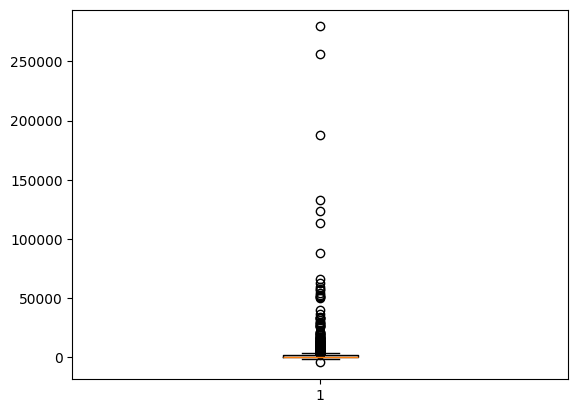

In [ ]:
# outlier treatment for 'Amount.'
plt.boxplot(RFM.Amount)


In [ ]:
Q1 = RFM.Amount.quantile(0.25)
Q3 = RFM.Amount.quantile(0.75)
IQR = Q3 - Q1
RFM = RFM[(RFM.Amount >= Q1 - 1.5*IQR) & (RFM.Amount <= Q3 + 1.5*IQR)]

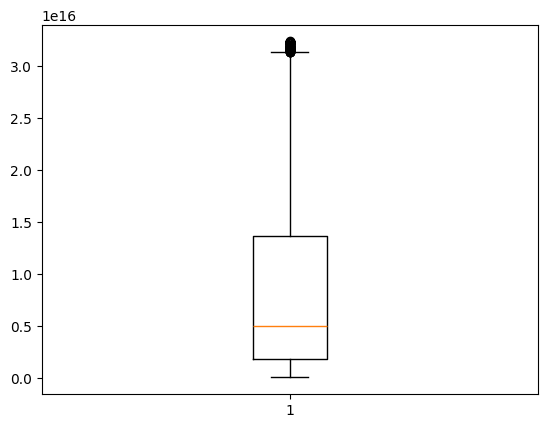

In [ ]:
# outlier treatment for 'Recency.'
plt.boxplot(RFM.Recency)
Q1 = RFM.Recency.quantile(0.25)
Q3 = RFM.Recency.quantile(0.75)
IQR = Q3 - Q1
RFM = RFM[(RFM.Recency >= Q1 - 1.5*IQR) & (RFM.Recency <= Q3 + 1.5*IQR)]

In [ ]:
# standardise all parameters
RFM_norm1 = RFM.drop("CustomerID", axis=1)


In [ ]:
RFM_norm1

,Frequency,Amount,Recency
0,2,0.00,326 days 02:33:00
2,31,1797.24,75 days 23:37:00
3,73,1757.55,19 days 02:59:00
4,17,334.40,310 days 20:49:00
5,95,1545.41,36 days 22:13:00
...,...,...,...
4367,10,180.60,278 days 02:58:00
4368,7,80.82,181 days 01:57:00
4369,13,176.60,8 days 01:07:00
4370,756,2094.88,4 days 00:48:00


In [ ]:
RFM_norm1['Recency'] = RFM_norm1['Recency'].dt.days

In [ ]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
RFM_norm1 = standard_scaler.fit_transform(RFM_norm1)

In [ ]:
RFM_norm1 = pd.DataFrame(RFM_norm1)
RFM_norm1.columns = ['Frequency', 'Amount', 'Recency']
RFM_norm1.head()

,Frequency,Amount,Recency
0,-0.783868,-1.065957,2.443383
1,-0.410310,1.137317,-0.193213
2,0.130704,1.088660,-0.781457
3,-0.590649,-0.656009,2.275313
4,0.414093,0.828593,-0.602883


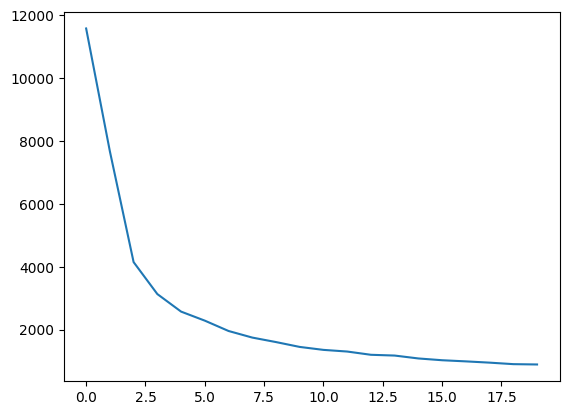

In [ ]:
# sum of squared distances
ssd = []
for num_clusters in list(range(1,21)):
    model_clus = KMeans(n_clusters = num_clusters, max_iter=50)
    model_clus.fit(RFM_norm1)
    ssd.append(model_clus.inertia_)

plt.plot(ssd)

In [ ]:
# K-means with K=3
model_clus3 = KMeans(n_clusters = 3, max_iter=50)
model_clus3.fit(RFM_norm1)

KMeans(max_iter=50, n_clusters=3)

In [ ]:
model_clus3.labels_

array([1, 2, 0, ..., 2, 0, 0], dtype=int32)

In [ ]:
RFM.index = pd.RangeIndex(len(RFM.index))
RFM_km = pd.concat([RFM, pd.Series(model_clus3.labels_)], axis=1)
RFM_km.columns = ['CustomerID', 'Frequency', 'Amount', 'Recency', 'ClusterID']

RFM_km.Recency = RFM_km.Recency.dt.days
km_clusters_amount =    pd.DataFrame(RFM_km.groupby(["ClusterID"]).Amount.mean())
km_clusters_frequency =     pd.DataFrame(RFM_km.groupby(["ClusterID"]).Frequency.mean())
km_clusters_recency =   pd.DataFrame(RFM_km.groupby(["ClusterID"]).Recency.mean())

In [ ]:
df = pd.concat([pd.Series([0,1,2]), km_clusters_amount, km_clusters_frequency, km_clusters_recency], axis=1)
df.columns = ["ClusterID", "Amount_mean", "Frequency_mean", "Recency_mean"]
df.head()


,ClusterID,Amount_mean,Frequency_mean,Recency_mean
0,0,2198.167400,168.857516,34.592157
1,1,371.715642,24.762590,238.315519
2,2,619.016466,42.122881,48.183616


<Axes: xlabel='ClusterID', ylabel='Amount_mean'>

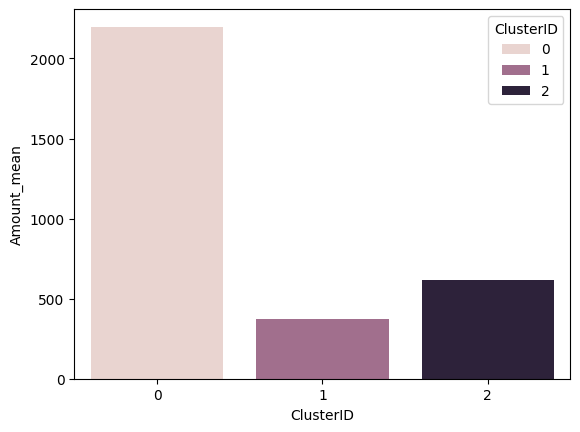

In [ ]:
sns.barplot(x=df.ClusterID, y=df.Amount_mean, hue=df.ClusterID)


<Axes: xlabel='ClusterID', ylabel='Frequency_mean'>

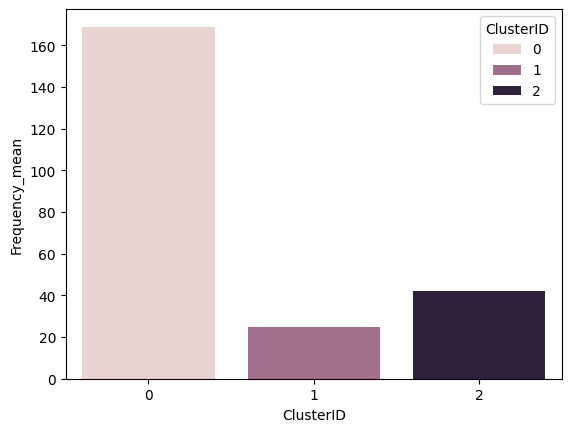

In [ ]:
sns.barplot(x=df.ClusterID, y=df.Frequency_mean,hue=df.ClusterID)


<Axes: xlabel='ClusterID', ylabel='Recency_mean'>

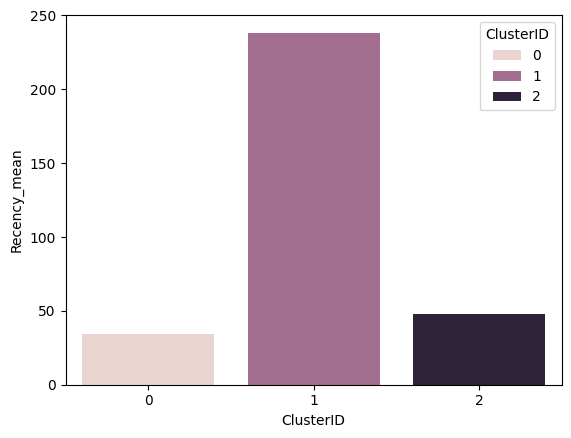

In [ ]:
sns.barplot(x=df.ClusterID, y=df.Recency_mean,hue=df.ClusterID)


After analyzing the above bar plots, we can conclude the following:

Customers in cluster 1 on average spend the most, they frequently visit the store, and recency is the least, that is, re-orders. These customers are our loyal customers, and we should plan to reward them.
Customers in cluster 2 are spending less, their frequency of visit to the store is less, but their re-order rate, that is the recency, is lower, which means we'll have to figure out a way to make them more frequent customers, ensuring they spend more on average
Customers in cluster 0 spend less, their frequency of visit is the lowest, and their recency is the highest, which means the reorder time period is too huge; we need to figure out the reason for this, and we can decide whether to drop these customers or not.